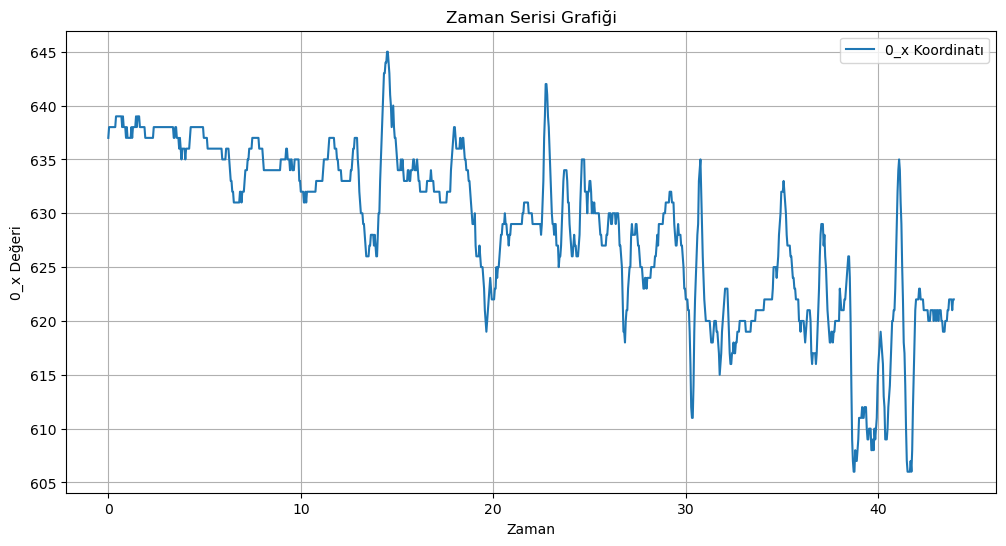

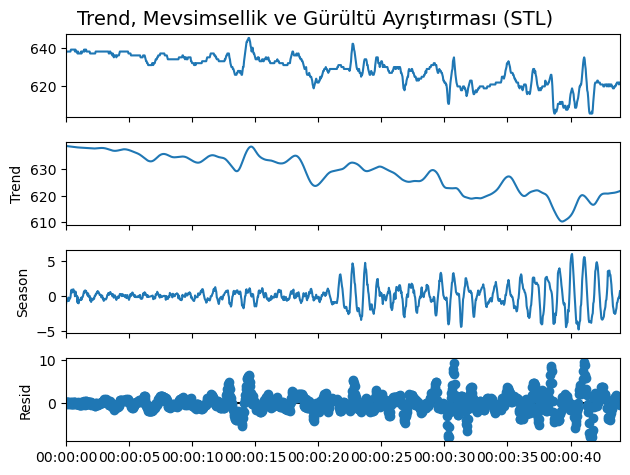

Time column is increasing: True
Missing values:
time    0
0_x     0
dtype: int64


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. Veri Setini Yükleme
df = pd.read_csv("data/lip_0_x.csv")
df.head()

# Zaman serisini çizelim
plt.figure(figsize=(12, 6))
plt.plot(df['time'], df['0_x'], label='0_x Koordinatı')
plt.xlabel('Zaman')
plt.ylabel('0_x Değeri')
plt.title('Zaman Serisi Grafiği')
plt.legend()
plt.grid(True)
plt.show()

# STL (Seasonal-Trend Decomposition) ile ayrıştırma işlemi
# Öncelikle zaman serisini düzgün indeksli hale getirelim
time_series = pd.Series(df['0_x'].values, index=pd.to_datetime(df['time'], unit='s'))

stl = STL(time_series, period=25)  # period, verinin bilinen periyodikliğine göre seçilmelidir, varsayılan değer kullanıldı
result = stl.fit()

# Ayrıştırılan bileşenlerin grafiklerini çizelim
result.plot()
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.suptitle('Trend, Mevsimsellik ve Gürültü Ayrıştırması (STL)', fontsize=14)
plt.show()

# 2. Zaman Serisi Doğrulama
print("Time column is increasing:", df['time'].is_monotonic_increasing)
print("Missing values:")
print(df.isnull().sum())

# 3. Zaman Serisi Görselleştirme
#plt.figure(figsize=(12, 6))
#plt.plot(df['time'], df['0_x'], label="Time Series Data", color="blue")
#plt.xlabel("Time")
#plt.ylabel("Value")
#plt.title("Time Series Plot of 0_x")
#plt.legend()
#plt.grid(True)
#plt.show()

In [2]:
# 4. ADF Durağanlık Testi
adf_test = adfuller(df['0_x'])
print("ADF Statistic:", adf_test[0])
print("p-value:", adf_test[1])
print("Critical Values:", adf_test[4])

# Durağan olup olmadığını kontrol etme
if adf_test[1] < 0.05:
    print("Sonuç: Seri durağandır (Stationary)")
else:
    print("Sonuç: Seri durağan değildir (Non-Stationary)")
    
# p-değeri, hipotez testinde zaman serisinin durağan olup olmadığını anlamamıza yardımcı olur.
# p-değeri=0.2194 (0.05'ten büyük!)
# ADF istatistiği kritik değerlerden daha küçükse, seriyi durağan kabul edebiliriz.
# %1 seviyesinde (-3.4364) durağan değil ❌
# %5 seviyesinde (-2.8642) durağan değil ❌
# %10 seviyesinde (-2.5682) durağan değil ❌
# ADF istatistiği, kritik değerlerden büyük olduğu için serinin durağan olmadığı sonucuna ulaşıyoruz.

ADF Statistic: -2.1645442528685397
p-value: 0.2193645005987338
Critical Values: {'1%': -3.4364137337554785, '5%': -2.864217382986235, '10%': -2.568195530545688}
Sonuç: Seri durağan değildir (Non-Stationary)


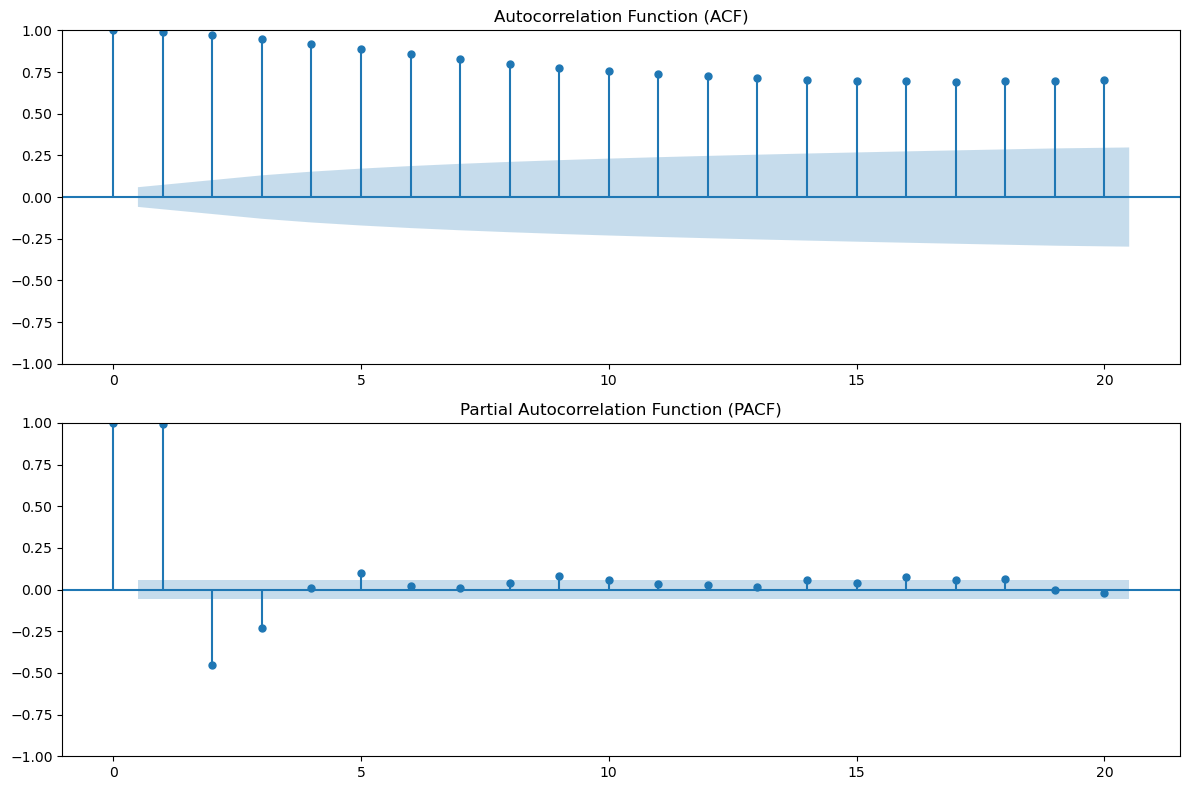

In [3]:
# 5. ACF ve PACF Grafikleri
fig, ax = plt.subplots(2, 1, figsize=(12, 8))
plot_acf(df['0_x'].dropna(), ax=ax[0], lags=20)
ax[0].set_title("Autocorrelation Function (ACF)")
plot_pacf(df['0_x'].dropna(), ax=ax[1], lags=20)
ax[1].set_title("Partial Autocorrelation Function (PACF)")
plt.tight_layout()
plt.show()

In [4]:
# 6. Durağanlık İçin Fark Alma İşlemi
df['0_x_diff'] = df['0_x'].diff()
adf_test_diff = adfuller(df['0_x_diff'].dropna())
print("ADF Statistic after differencing:", adf_test_diff[0])
print("p-value after differencing:", adf_test_diff[1])

ADF Statistic after differencing: -11.978892038028363
p-value after differencing: 3.745100821121786e-22


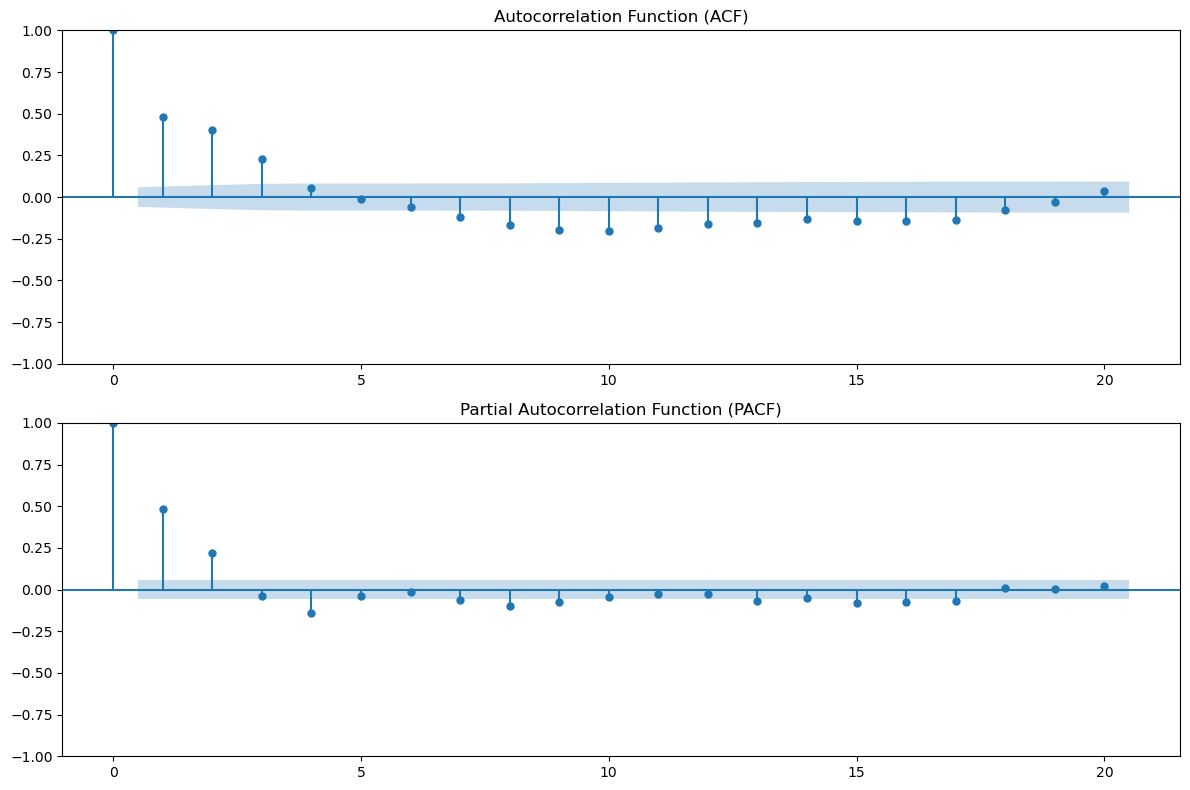

In [5]:
# 7. ACF ve PACF Grafikleri
fig, ax = plt.subplots(2, 1, figsize=(12, 8))
plot_acf(df['0_x_diff'].dropna(), ax=ax[0], lags=20)
ax[0].set_title("Autocorrelation Function (ACF)")
plot_pacf(df['0_x_diff'].dropna(), ax=ax[1], lags=20)
ax[1].set_title("Partial Autocorrelation Function (PACF)")
plt.tight_layout()
plt.show()

                               SARIMAX Results                                
Dep. Variable:                    0_x   No. Observations:                  879
Model:                 ARIMA(1, 1, 0)   Log Likelihood               -1074.611
Date:                Tue, 18 Mar 2025   AIC                           2153.221
Time:                        22:34:29   BIC                           2162.777
Sample:                             0   HQIC                          2156.876
                                - 879                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3932      0.022     17.496      0.000       0.349       0.437
sigma2         0.6769      0.022     30.844      0.000       0.634       0.720
Ljung-Box (L1) (Q):                   6.53   Jarque-

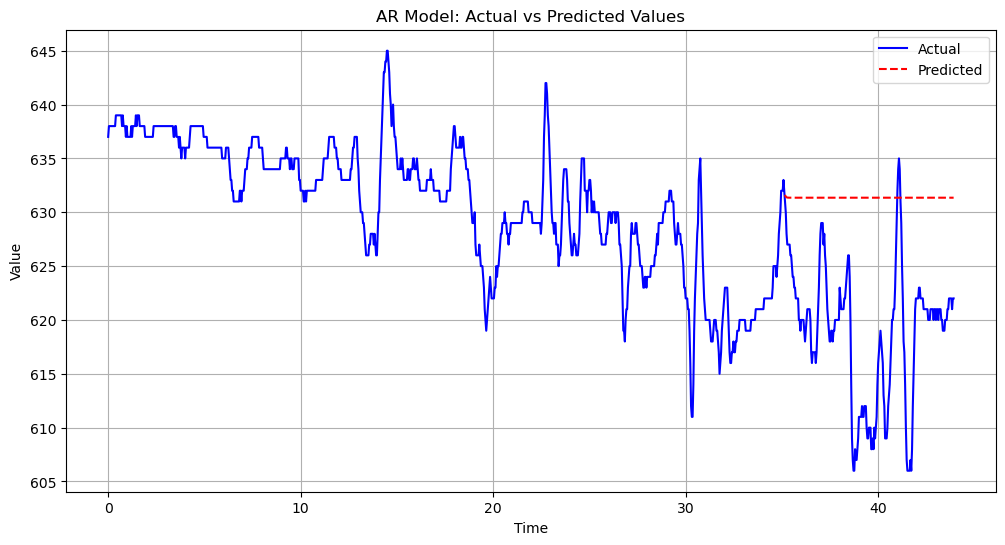

In [10]:
# 8. Veri Setini Train ve Test olarak Bölme
train_size = int(len(df) * 0.8)  # %80 eğitim, %20 test
train, test = df['0_x'][:train_size], df['0_x'][train_size:]

# 9. Modeli Sadece Train Verisinde Eğitme
model = ARIMA(train, order=(1, 1, 0))
model_fit = model.fit()
print(model_fit.summary())

# 10. Test Verisi İçin Tahmin Yapma
predictions = model_fit.forecast(steps=len(test))

# 11. Tahminleri Görselleştirme
plt.figure(figsize=(12, 6))
plt.plot(df['time'], df['0_x'], label="Actual", color="blue")
plt.plot(df['time'][train_size:], predictions, label="Predicted", linestyle="dashed", color="red")
plt.xlabel("Time")
plt.ylabel("Value")
plt.title("AR Model: Actual vs Predicted Values")
plt.legend()
plt.grid(True)
plt.show()

In [11]:
# 12. Performans Metriklerini Hesaplama
actual_values = test.values
predicted_values = predictions.values

mae = mean_absolute_error(actual_values, predicted_values)
mse = mean_squared_error(actual_values, predicted_values)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((actual_values - predicted_values) / actual_values)) * 100

print("Gerçek Değerler vs Tahmin Edilen Değerler:")
for actual, predicted in zip(actual_values, predicted_values):
    print(f"Gerçek: {actual}, Tahmin: {predicted}")

print("------------------------------------------------------------------------------")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"Mean Absolute Percentage Error (MAPE): {mape}%")

Gerçek Değerler vs Tahmin Edilen Değerler:
Gerçek: 631, Tahmin: 631.6067846035166
Gerçek: 630, Tahmin: 631.452166255485
Gerçek: 628, Tahmin: 631.3913679404602
Gerçek: 627, Tahmin: 631.3674611069122
Gerçek: 627, Tahmin: 631.35806057188
Gerçek: 627, Tahmin: 631.3543641367701
Gerçek: 627, Tahmin: 631.3529106415727
Gerçek: 626, Tahmin: 631.3523391048825
Gerçek: 626, Tahmin: 631.3521143678562
Gerçek: 625, Tahmin: 631.3520259977973
Gerçek: 624, Tahmin: 631.3519912493296
Gerçek: 624, Tahmin: 631.351977585697
Gerçek: 623, Tahmin: 631.3519722129463
Gerçek: 623, Tahmin: 631.351970100298
Gerçek: 622, Tahmin: 631.3519692695721
Gerçek: 622, Tahmin: 631.3519689429179
Gerçek: 622, Tahmin: 631.3519688144725
Gerçek: 622, Tahmin: 631.3519687639657
Gerçek: 620, Tahmin: 631.3519687441056
Gerçek: 620, Tahmin: 631.3519687362964
Gerçek: 619, Tahmin: 631.3519687332257
Gerçek: 620, Tahmin: 631.3519687320182
Gerçek: 620, Tahmin: 631.3519687315435
Gerçek: 620, Tahmin: 631.3519687313568
Gerçek: 620, Tahmin: 631.3